## **FIFA PLAYER STATISTICS ANALYSIS**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("fifa_csv.csv")

In [4]:
df.head()

,Unnamed: 0,sofifa_id,player_url,short_name,long_name,age,dob,height_cm,weight_kg,nationality,...,mentality_penalties,mentality_composure,defending_marking,defending_standing_tackle,defending_sliding_tackle,goalkeeping_diving,goalkeeping_handling,goalkeeping_kicking,goalkeeping_positioning,goalkeeping_reflexes
0,0,158023,https://sofifa.com/player/158023/lionel-messi/...,L. Messi,Lionel Andrés Messi Cuccittini,27,1987-06-24,169,67,Argentina,...,76,NaN,25,21,20,6,11,15,14,8
1,1,20801,https://sofifa.com/player/20801/c-ronaldo-dos-...,Cristiano Ronaldo,Cristiano Ronaldo dos Santos Aveiro,29,1985-02-05,185,80,Portugal,...,85,NaN,22,31,23,7,11,15,14,11
2,2,9014,https://sofifa.com/player/9014/arjen-robben/15...,A. Robben,Arjen Robben,30,1984-01-23,180,80,Netherlands,...,80,NaN,29,26,26,10,8,11,5,15
3,3,41236,https://sofifa.com/player/41236/zlatan-ibrahim...,Z. Ibrahimović,Zlatan Ibrahimović,32,1981-10-03,195,95,Sweden,...,91,NaN,25,41,27,13,15,10,9,12
4,4,167495,https://sofifa.com/player/167495/manuel-neuer/...,M. Neuer,Manuel Neuer,28,1986-03-27,193,92,Germany,...,37,NaN,25,25,25,87,85,92,90,86


In [6]:
print('shape:',df.shape)


shape: (16155, 81)


**EDA**

In [12]:
print(df.dtypes.value_counts().to_dict())
df.info()

{dtype('int64'): 45, dtype('O'): 18, dtype('float64'): 18}
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16155 entries, 0 to 16154
Data columns (total 81 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Unnamed: 0                  16155 non-null  int64  
 1   sofifa_id                   16155 non-null  int64  
 2   player_url                  16155 non-null  object 
 3   short_name                  16155 non-null  object 
 4   long_name                   16155 non-null  object 
 5   age                         16155 non-null  int64  
 6   dob                         16155 non-null  object 
 7   height_cm                   16155 non-null  int64  
 8   weight_kg                   16155 non-null  int64  
 9   nationality                 16155 non-null  object 
 10  club_name                   15916 non-null  object 
 11  league_name                 15916 non-null  object 
 12  league_rank                 1

**Missing Values**

In [19]:
missing_report = pd.DataFrame({
            "Missing Values": df.isnull().sum(),
            "Percentage (%)": (df.isnull().sum() / len(df)*100).round(2)})
missing_report = missing_report[
    missing_report["Missing Values"] > 0].sort_values(
            by = "Missing Values",
            ascending = False
)
print("Coloumn with Missing Values:", len(missing_report))
missing_report.head(10)

Coloumn with Missing Values: 26


,Missing Values,Percentage (%)
mentality_composure,16155,100.00
release_clause_eur,16155,100.00
loaned_from,15243,94.35
nation_position,15074,93.31
nation_jersey_number,15074,93.31
player_tags,14919,92.35
gk_positioning,14380,89.01
gk_speed,14380,89.01
gk_reflexes,14380,89.01
gk_kicking,14380,89.01


In [44]:
print(df.columns.tolist())

['Unnamed: 0', 'sofifa_id', 'player_url', 'short_name', 'long_name', 'Age', 'dob', 'height_cm', 'weight_kg', 'Nationality', 'Club', 'league_name', 'league_rank', 'Overall', 'Potential', 'Value', 'Wage', 'Position', 'preferred_foot', 'international_reputation', 'weak_foot', 'skill_moves', 'work_rate', 'body_type', 'real_face', 'release_clause_eur', 'player_tags', 'team_position', 'team_jersey_number', 'loaned_from', 'joined', 'contract_valid_until', 'nation_position', 'nation_jersey_number', 'pace', 'shooting', 'passing', 'dribbling', 'defending', 'physic', 'gk_diving', 'gk_handling', 'gk_kicking', 'gk_reflexes', 'gk_speed', 'gk_positioning', 'player_traits', 'attacking_crossing', 'attacking_finishing', 'attacking_heading_accuracy', 'attacking_short_passing', 'attacking_volleys', 'skill_dribbling', 'skill_curve', 'skill_fk_accuracy', 'skill_long_passing', 'skill_ball_control', 'movement_acceleration', 'movement_sprint_speed', 'movement_agility', 'movement_reactions', 'movement_balance',

In [45]:
df.rename(columns = {
    'age': 'Age',
    'overall': 'Overall',
    'potential': 'Potential',
    'value_eur': 'Value',
    'wage_eur': 'Wage',
    'club_name': 'Club',
    'nationality': 'Nationality',
    'player_positions': 'Position'
},
inplace = True)

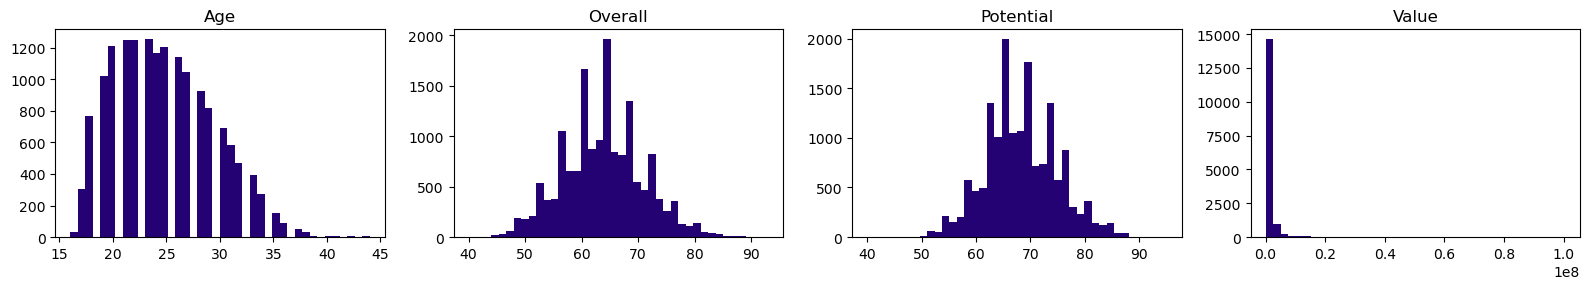

,Age,Overall,Potential,Value
count,16155.00,16155.00,16155.00,1.615500e+04
mean,24.78,63.83,68.35,1.060882e+06
std,4.63,7.17,6.58,2.819128e+06
min,16.00,40.00,40.00,0.000000e+00
25%,21.00,59.00,64.00,1.200000e+05
50%,24.00,64.00,68.00,3.500000e+05
75%,28.00,68.00,73.00,8.250000e+05
max,44.00,93.00,95.00,1.005000e+08


In [47]:
num = ['Age' , 'Overall' , 'Potential' , 'Value']
num = [c for c in num if c in df.columns]
fig,ax = plt.subplots(1,len(num) , figsize = (4*len(num) , 3))
ax = np.atleast_1d(ax)
for a,c in zip(ax , num):
    a.hist(df[c].dropna() , bins = 40 , color = '#240274'); a.set_title(c)
plt.tight_layout(); plt.show()
df[num].describe().round(2)

**Top Categories**

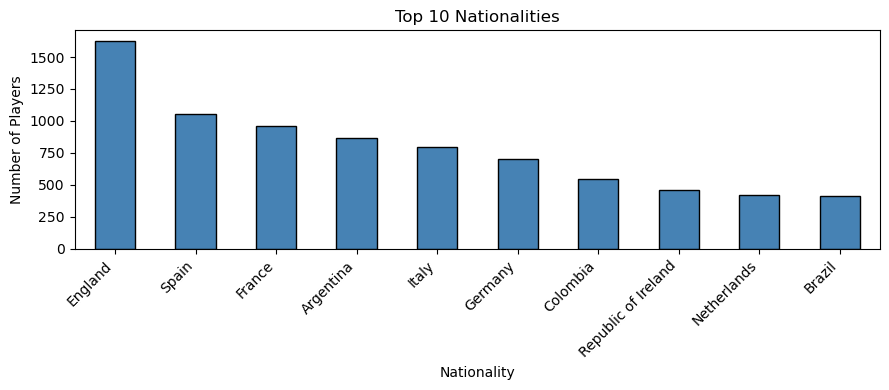

Nationality
England                1627
Spain                  1051
France                  958
Argentina               867
Italy                   795
Germany                 701
Colombia                543
Republic of Ireland     460
Netherlands             419
Brazil                  416


In [51]:
vc = df['Nationality'].dropna().value_counts().head(10)

fig, ax = plt.subplots(figsize = (9,4))

vc.plot(
    kind = 'bar',
    ax = ax,
    color = 'steelblue',
    edgecolor = 'black'
)
ax.set_title("Top 10 Nationalities")
ax.set_xlabel("Nationality")
ax.set_ylabel("Number of Players")

plt.xticks(rotation = 45 , ha = 'right')
plt.tight_layout()

plt.show()

print(vc.to_string())